## 4. PCA and K-Means (20 points):

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
df = pd.read_csv("mobile_price.csv")

# 2. Split the data into features (X) and labels (y)
X = df.drop('price_range', axis=1)
y = df['price_range']

# 3. Standardize the features using z-score standardization
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# Optional: Convert the scaled array back to a Pandas DataFrame for better readability 
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

# Display the first 5 rows to verify the standardization
print("Standardized Features (First 5 rows):")
display(X_scaled.head())

Standardized Features (First 5 rows):


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099


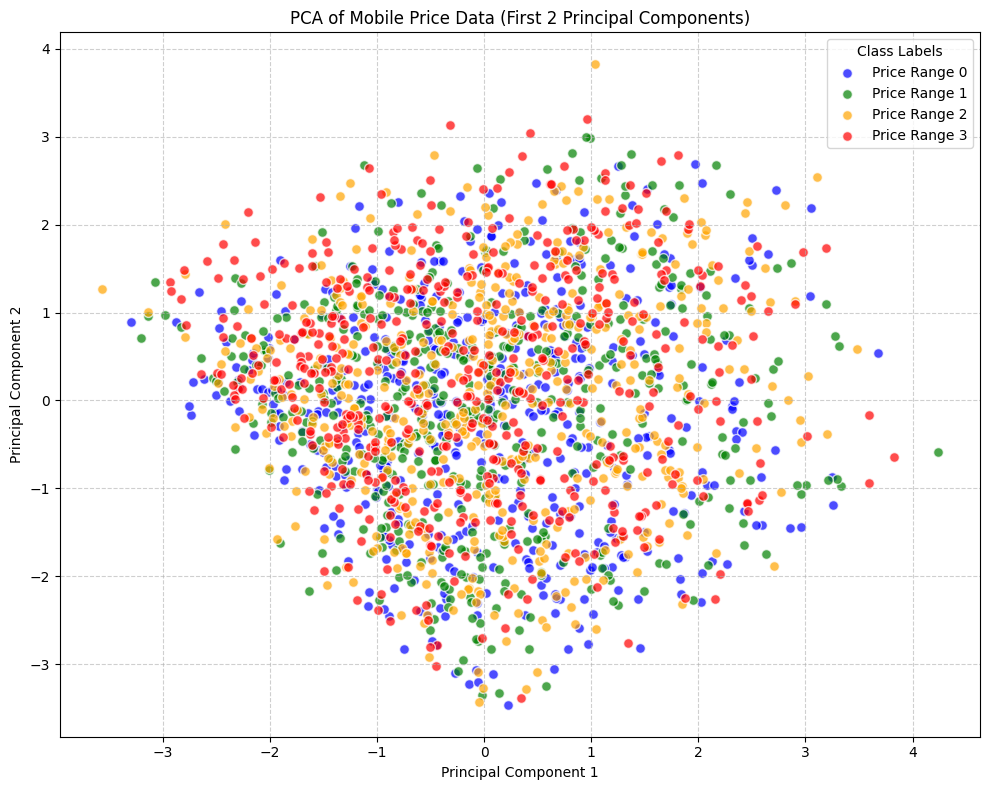

In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Initialize PCA to project the features onto 2 dimensions
pca = PCA(n_components=2, random_state=42)

# 2. Fit and transform the standardized features (from 4a)
X_pca = pca.fit_transform(X_scaled)

# 3. Visualize the scatterplot
plt.figure(figsize=(10, 8))

# Define the unique class labels and a color map
classes = sorted(y.unique())
colors = ['blue', 'green', 'orange', 'red']

# Plot each class separately to automatically generate a precise legend
for cls, color in zip(classes, colors):
    # Filter the indices where the label matches the current class
    idx = (y == cls)
    plt.scatter(
        X_pca[idx, 0], 
        X_pca[idx, 1], 
        c=color, 
        label=f'Price Range {cls}', 
        alpha=0.7, 
        edgecolors='w',
        s=50
    )

# 4. Format the plot
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Mobile Price Data (First 2 Principal Components)')
plt.legend(title='Class Labels', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()

K-Means Clustering Performance (All Features):
Adjusted Rand Score: 0.0060



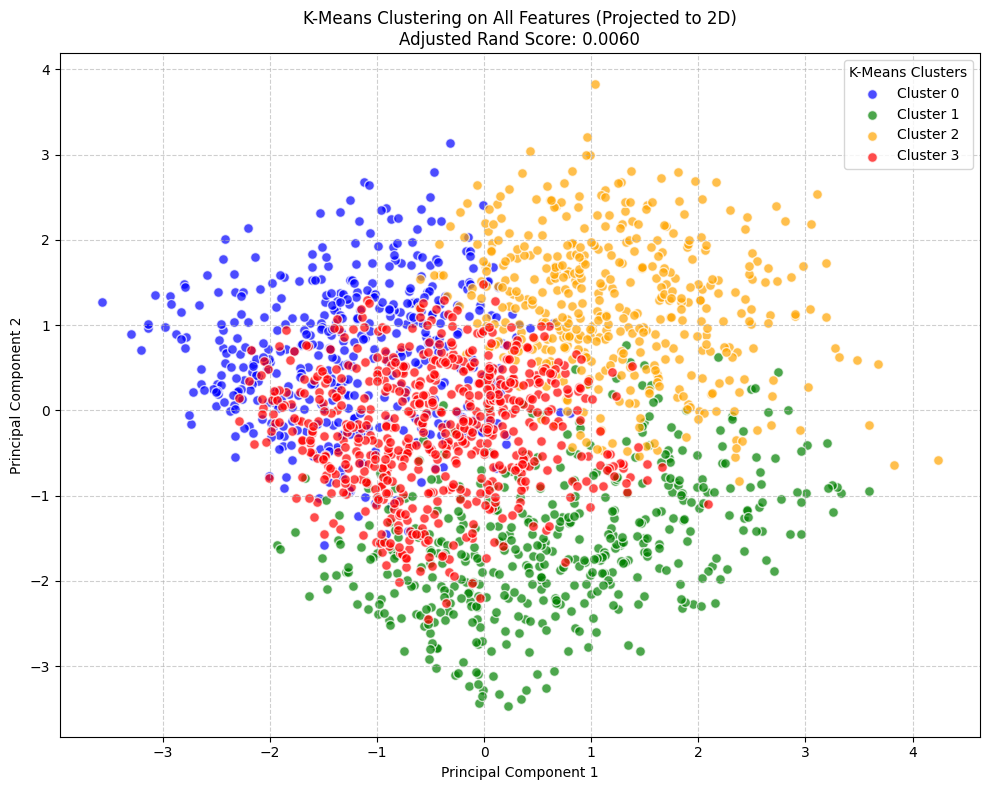

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt

# 1. Apply K-Means clustering to the standardized data using all features
# We explicitly set n_init=10 to suppress warnings and random_state for reproducibility
kmeans_all = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_all = kmeans_all.fit_predict(X_scaled)

# 2. Evaluate clustering performance using Adjusted Rand Score (ARI)
# ARI measures the similarity between the true labels (y) and the predicted clusters
ari_score_all = adjusted_rand_score(y, cluster_labels_all)

print(f"K-Means Clustering Performance (All Features):")
print(f"Adjusted Rand Score: {ari_score_all:.4f}\n")

# 3. Visualize the clustering results
# We use the X_pca components from Task 4(b) strictly for 2D visualization purposes
plt.figure(figsize=(10, 8))

# Define the unique clusters found
clusters = sorted(list(set(cluster_labels_all)))
colors = ['blue', 'green', 'orange', 'red']

# Plot each cluster separately to automatically generate a precise legend
for cluster, color in zip(clusters, colors):
    # Filter the indices where the generated label matches the current cluster
    idx = (cluster_labels_all == cluster)
    plt.scatter(
        X_pca[idx, 0], 
        X_pca[idx, 1], 
        c=color, 
        label=f'Cluster {cluster}', 
        alpha=0.7, 
        edgecolors='w',
        s=50
    )

# 4. Format the plot
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'K-Means Clustering on All Features (Projected to 2D)\nAdjusted Rand Score: {ari_score_all:.4f}')
plt.legend(title='K-Means Clusters', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()

K-Means Clustering Performance (2D PCA Features):
Adjusted Rand Score: 0.0017



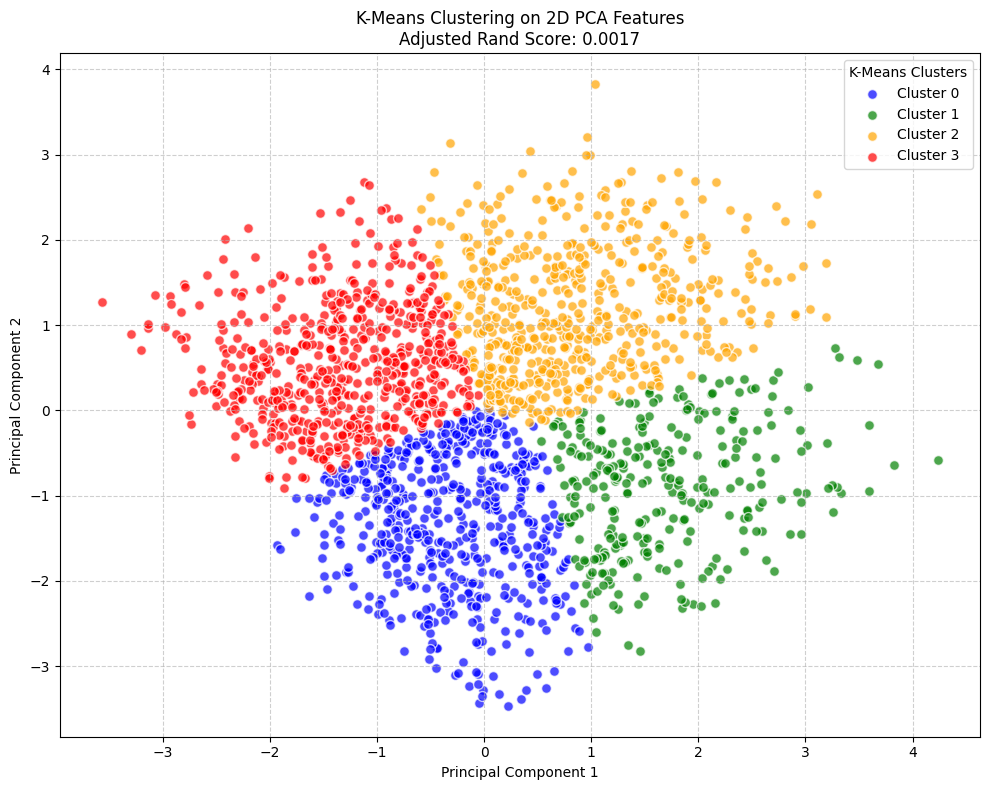

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt

# 1. Apply K-Means clustering using strictly the 2-dimensional PCA features
# We explicitly set n_clusters=4, n_init=10 to suppress warnings, and random_state=42
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_pca = kmeans_pca.fit_predict(X_pca)

# 2. Evaluate clustering performance using Adjusted Rand Score (ARI)
# ARI compares the true labels (y) to the new PCA-based cluster assignments
ari_score_pca = adjusted_rand_score(y, cluster_labels_pca)

print(f"K-Means Clustering Performance (2D PCA Features):")
print(f"Adjusted Rand Score: {ari_score_pca:.4f}\n")

# 3. Visualize the clustering results
plt.figure(figsize=(10, 8))

# Define the unique clusters found
clusters = sorted(list(set(cluster_labels_pca)))
colors = ['blue', 'green', 'orange', 'red']

# Plot each cluster separately to automatically generate a precise legend
for cluster, color in zip(clusters, colors):
    # Filter the indices where the generated label matches the current cluster
    idx = (cluster_labels_pca == cluster)
    plt.scatter(
        X_pca[idx, 0], 
        X_pca[idx, 1], 
        c=color, 
        label=f'Cluster {cluster}', 
        alpha=0.7, 
        edgecolors='w',
        s=50
    )

# 4. Format the plot
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'K-Means Clustering on 2D PCA Features\nAdjusted Rand Score: {ari_score_pca:.4f}')
plt.legend(title='K-Means Clusters', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()